# CRISPR-Cas Atlast Cas13b summary

This notebook contains analysis for summarising Cas13b operons from CRIPSR-Cas Atlas data.

### Import modules

In [2]:
import sys, os, re
import pandas as pd
from plotnine import (ggplot, aes, geom_histogram, geom_density, theme_bw, 
                      labs, theme, element_text, scale_x_continuous, geom_vline, 
                      geom_boxplot, geom_jitter, scale_x_discrete, stat_summary,
                      scale_y_continuous, scale_fill_manual, scale_color_manual, geom_hline,
                      element_blank, theme_classic)

## General summary

Distributions for various properties of Cas13b CRISPR operons

In [3]:
home_dir = os.path.expanduser("~")
data_dir = os.path.join(home_dir, "work", "spacer_analysis", "atlas_summary", "data")
summary_file = os.path.join(data_dir, "raw", "cas13b_vi_summary.csv")

In [4]:
df = pd.read_csv(summary_file, header=0)

/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 52'. Pick better value with 'binwidth'.


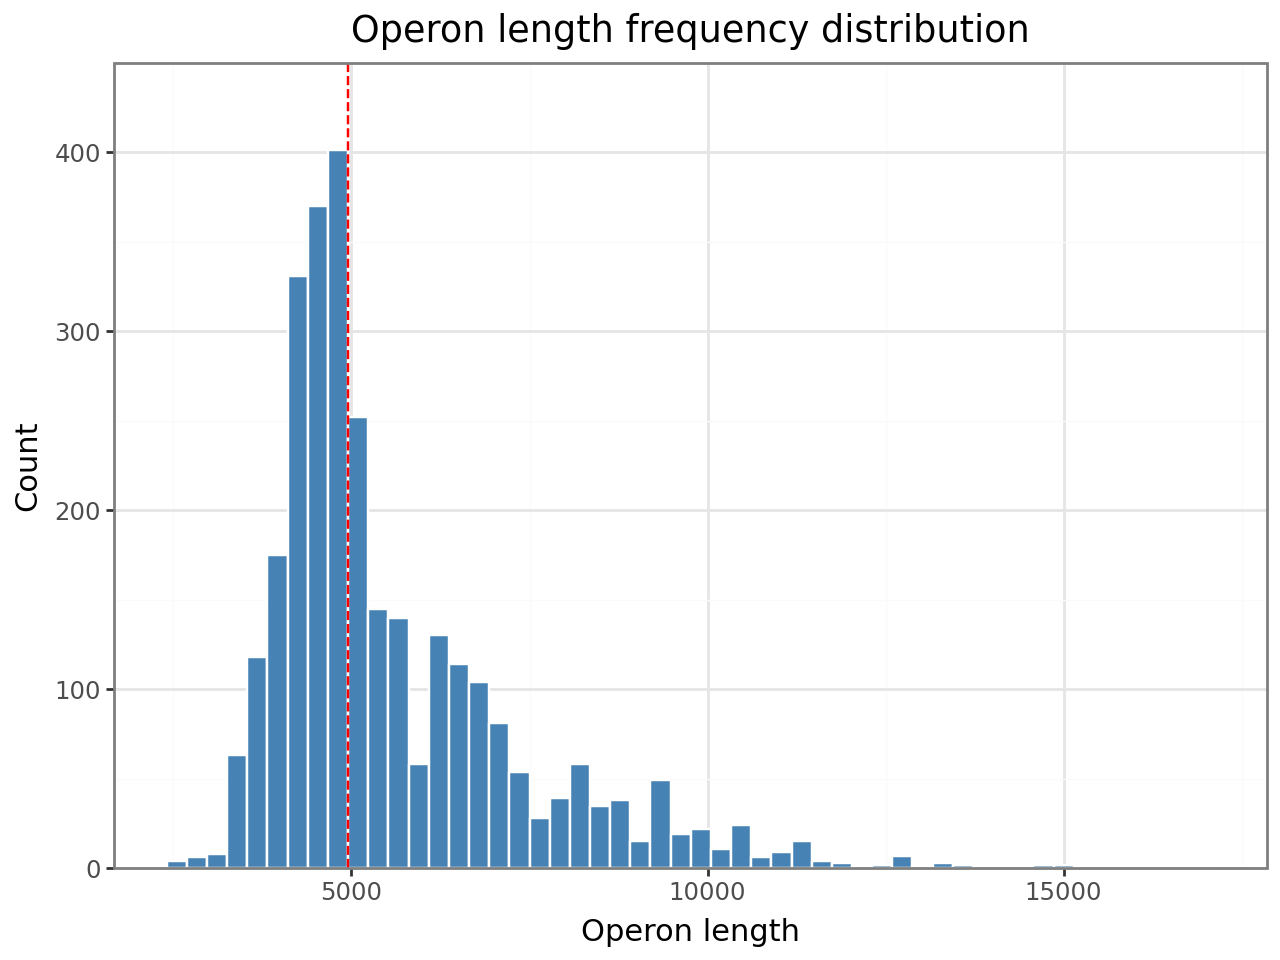

In [5]:
stats = df['operon_length'].describe()

median_val = df['operon_length'].median()

p_freq = (
    ggplot(df, aes(x='operon_length'))
           + geom_histogram(fill='steelblue', color='white')
           + geom_vline(xintercept=median_val, color='red', linetype='dashed', size=0.5)
           + scale_y_continuous(expand=(0, 0),
                                limits=(0, 450))
           + labs(title='Operon length frequency distribution', x='Operon length', y='Count')
           + theme_bw()
)
display(p_freq)

/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 59'. Pick better value with 'binwidth'.
/home/unimelb.edu.au/rbengtsson/miniconda3/envs/modules/lib/python3.10/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_histogram : Removed 1 rows containing missing values.


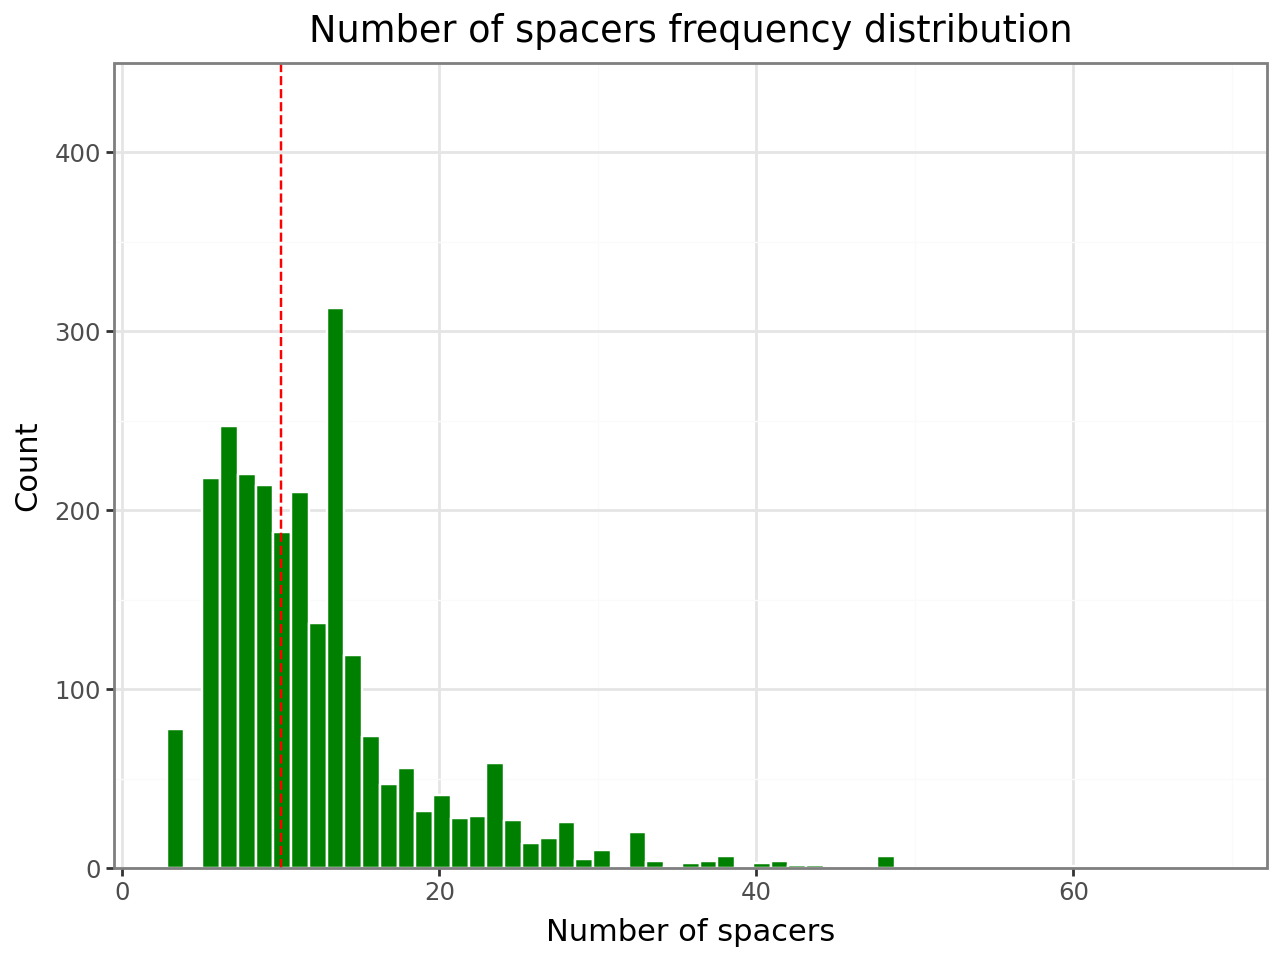

In [6]:
median_val = df['n_spacers'].median()

p_freq = (
    ggplot(df, aes(x='n_spacers'))
           + geom_histogram(fill='green', color='white')
           + geom_vline(xintercept=median_val, color='red', linetype='dashed', size=0.5)
           + scale_y_continuous(expand=(0, 0),
                                limits=(0, 450))
           + labs(title='Number of spacers frequency distribution', x='Number of spacers', y='Count')
           + theme_bw()
)
display(p_freq)

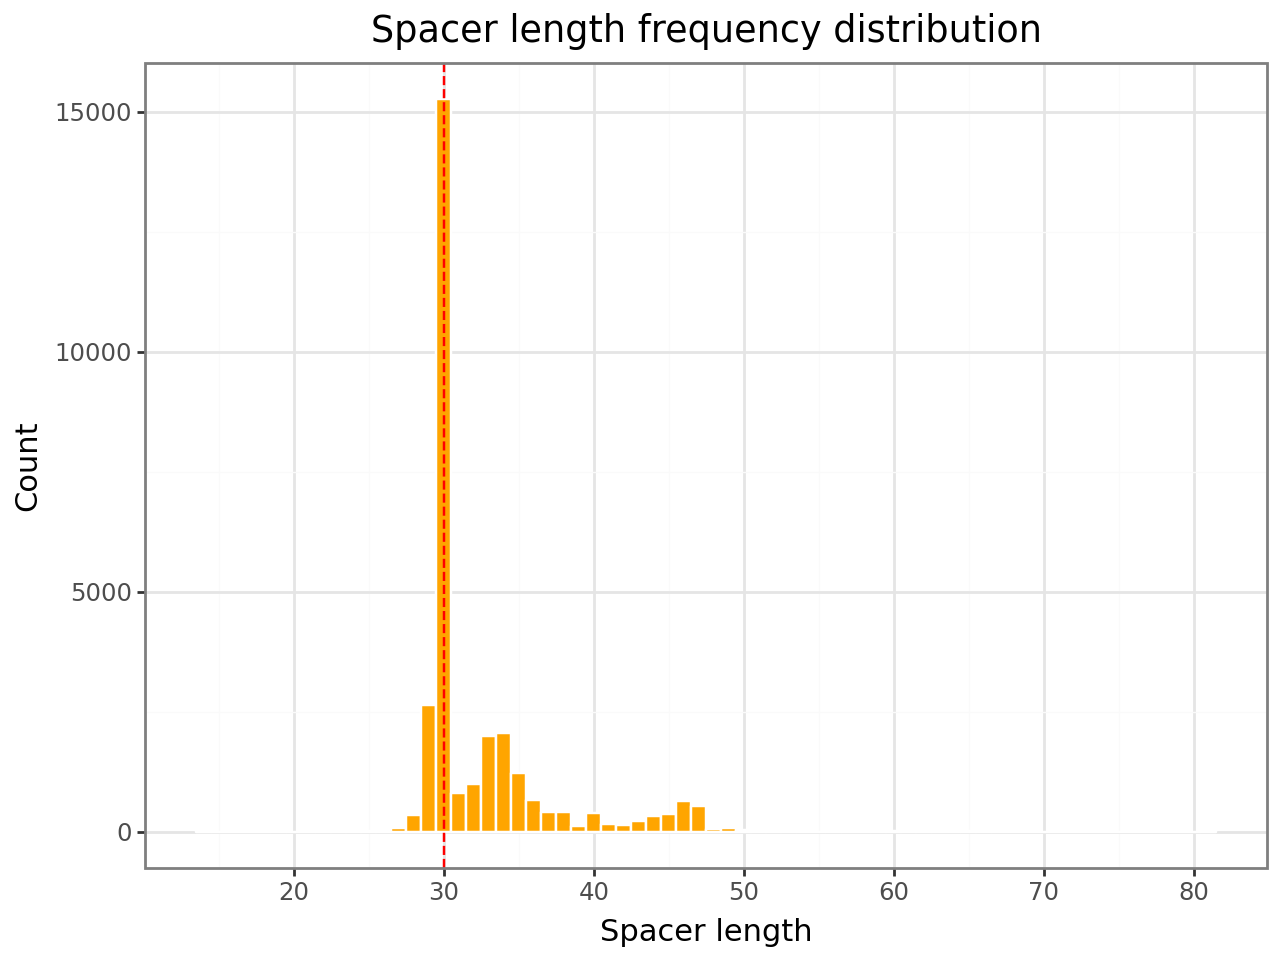

In [7]:
spacer_len_raw_file = os.path.join(data_dir, "raw", "cas13b_vi_spacers_len_raw.csv")
spacer_len_df = pd.read_csv(spacer_len_raw_file, header=0)

spacer_len_df = spacer_len_df[spacer_len_df['spacer_length'] < 100]

median_val = spacer_len_df['spacer_length'].median()

# print(spacer_len_df['spacer_length'].describe())

p_freq = (
    ggplot(spacer_len_df, aes(x='spacer_length'))
           + geom_histogram(fill='orange', color='white', binwidth=1)
           + geom_vline(xintercept=median_val, color='red', linetype='dashed', size=0.5)
           + scale_x_continuous(breaks=range(0, 100, 10))
        #    + scale_y_continuous(expand=(0, 0),
        #                         limits=(0, 450))
           + labs(title='Spacer length frequency distribution', x='Spacer length', y='Count')
           + theme_bw()
)
display(p_freq)

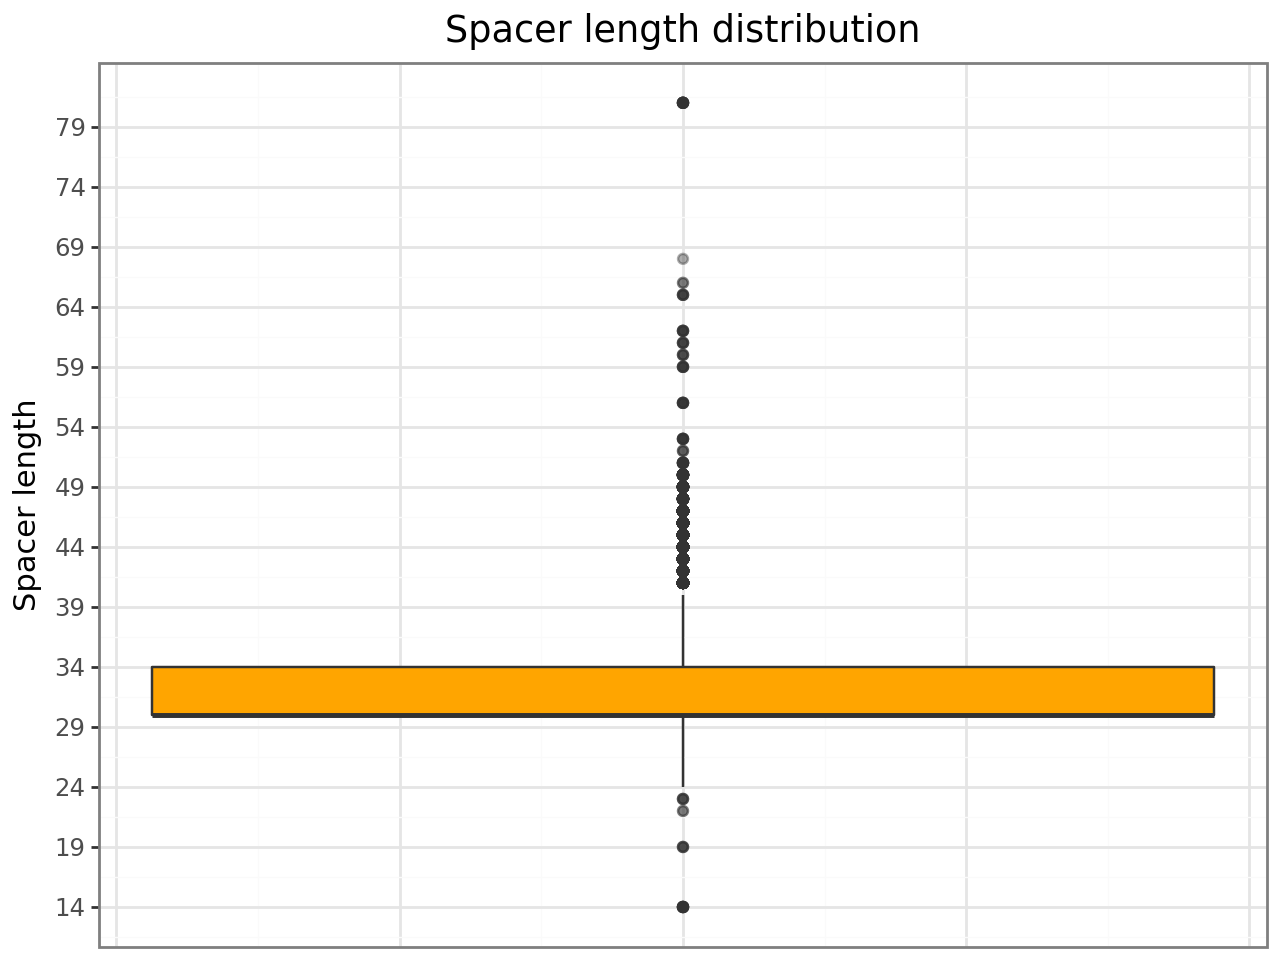

In [8]:
# set y-axis ticks at increments of 1
y_min = int(spacer_len_df['spacer_length'].min())
y_max = int(spacer_len_df['spacer_length'].max())

p_box = (
    ggplot(spacer_len_df, aes(x=1, y='spacer_length'))
    + geom_boxplot(fill='orange', outlier_alpha=0.4)
    + labs(title='Spacer length distribution', x='', y='Spacer length')
    + theme_bw()
    + theme(axis_text_x=element_blank(), axis_ticks_major_x=element_blank())
    + scale_y_continuous(breaks=list(range(y_min, y_max + 1, 5)))
)
p_box

Majority of spacer length is within 29 - 35 bp